# Benchmark 1D 

Example of creation of a multifidelity Neural Network to create the model that connects the input variables to the function itself. After that, it is possible to build a Markov Chain Monte Carlo alogoritm to discover the original input value, considered in general unknown

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras


from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


Ray module not found. Multiprocessing features are not available


True

In [2]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)


# Creation of the model

In [3]:
#Benchmark1
highfid = lambda x: (6.*x/5-2.)**2*np.sin(12.*x/5-4.)
lowfid  = lambda x: 0.5*highfid(x) + 10*(x/5-0.5) + 5.
Nhf = 5
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

NepoLF = 1000
NepoHF = 500

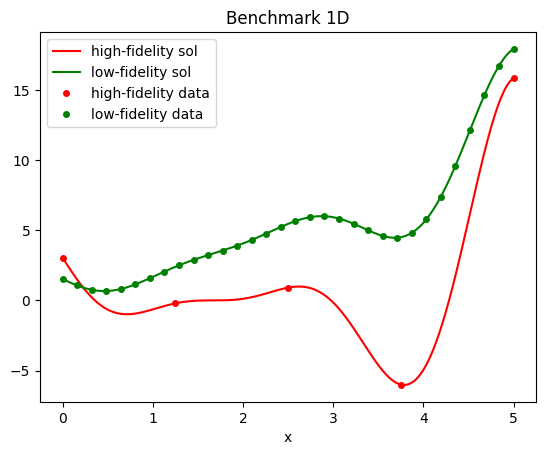

In [4]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model




The function training took 2.8145270347595215 seconds.


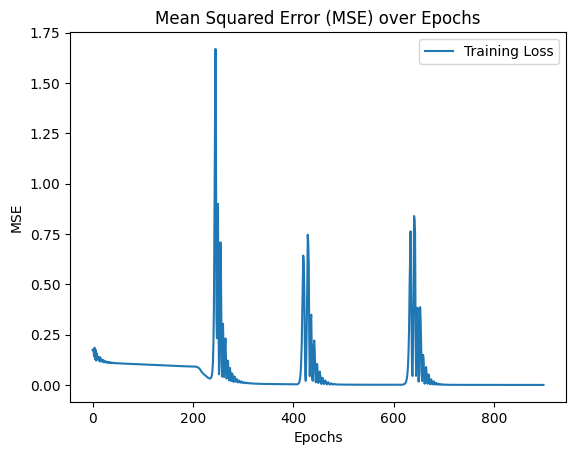

Test MSE: 32.570519687982234
R^2: -0.6318402266523682


In [5]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)
(mse_LF,R2_LF)=modelLF.performance(x_test,highfid(x_test))

## High fidelity model

The function training took 1.6430315971374512 seconds.


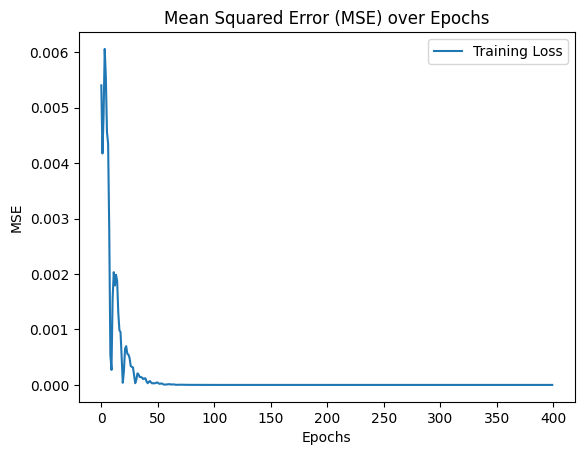

Test MSE: 14.920880731208884
R^2: 0.2524376759252973


In [6]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
(mse_HF,R2_HF)=modelHF.performance(x_test,highfid(x_test))

## 2 Step model

The function training took 2.586879014968872 seconds.


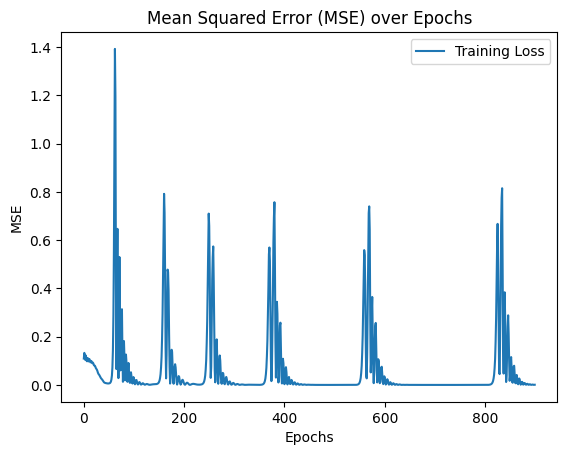

The function training took 1.2136220932006836 seconds.


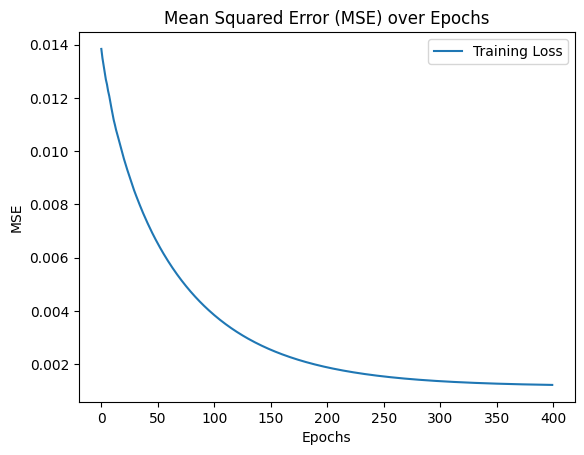

Test MSE: 0.7800934504672069
R^2: 0.9609159483724744


In [7]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','HF']

params=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params,data_train=[xlf,xhf],output_train=[Ylf,Yhf],N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
(mse_MF,R2_MF)=final_model.model_list[1].performance(input_HF,highfid(x_test))

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

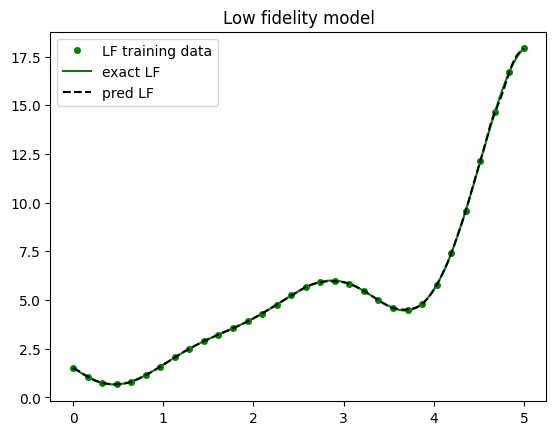

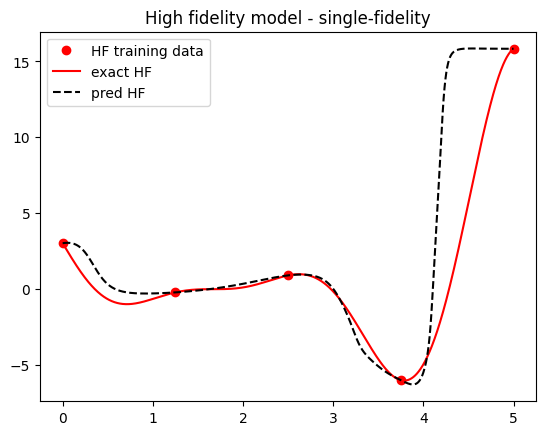

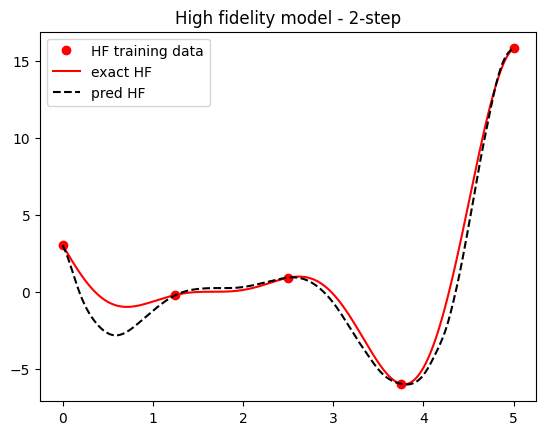

In [8]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC using CuqiPy

In [11]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([0.2,0.3,0.4,0.45])*5
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.2
sigma=0.3
#rwmh_cov = np.eye(len(real_x)) # !

iterations =20
burnin = 1
n_chains=2

Sample 20 / 20

Average acceptance rate: 0.21052631578947367 MCMC scale: 0.2619721502562528 

********************  # Mean values = [1.32971094 0.17814342 0.63110908 0.17909431]  ********************
Sample 17 / 20

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 20 / 20

Average acceptance rate: 0.21052631578947367 MCMC scale: 0.24783489112686916 

********************  # Mean values = [1.0228023  0.52905025 0.421051   0.4854731 ]  ********************
(2, 4, 19)


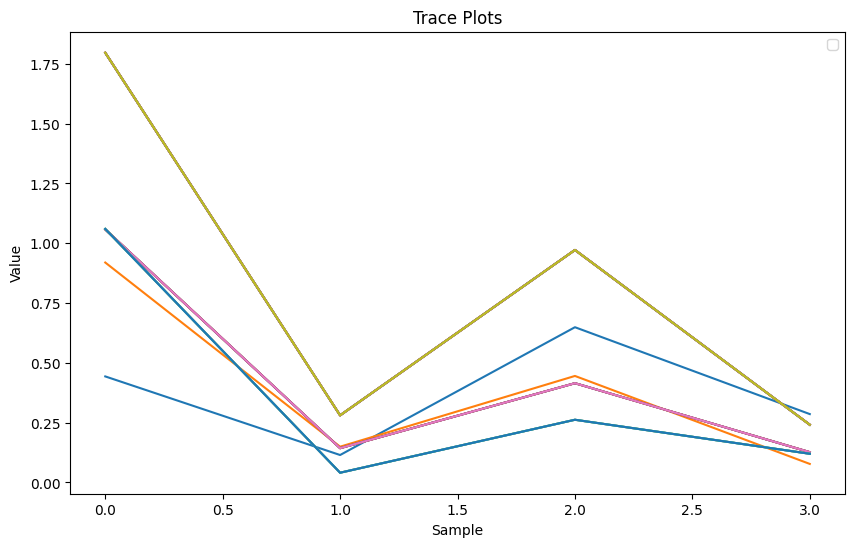

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


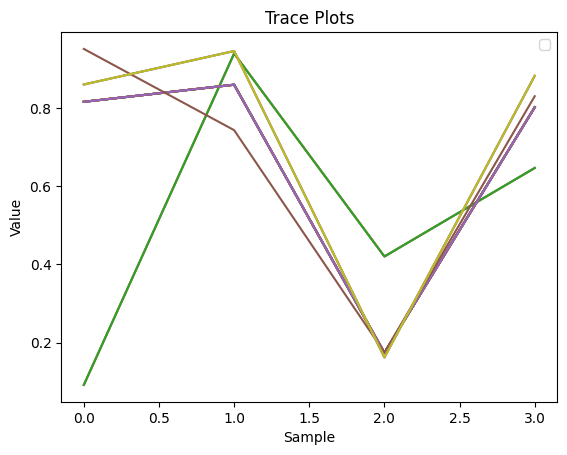

[0.92105263 0.31578947 0.23684211 0.21052632 0.05263158 0.
 0.10526316 0.02631579 0.65789474 0.57894737 0.31578947 0.23684211
 0.         0.         0.         0.         0.         0.
 0.         0.21052632]


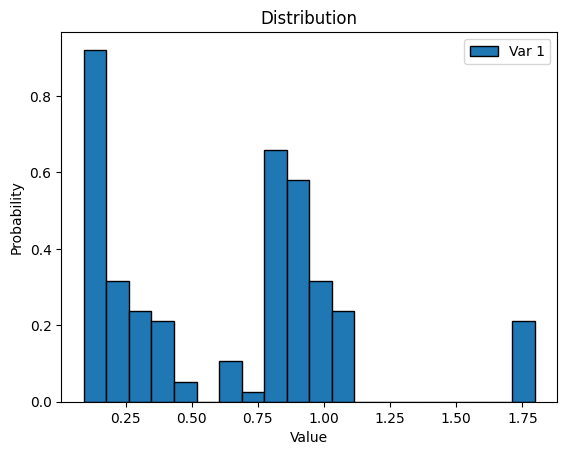

[0.13157895 0.34210526 0.57894737 0.         0.31578947 0.23684211
 0.         0.         0.26315789 0.         0.         0.
 0.         0.10526316 0.         0.02631579 0.31578947 0.34210526
 0.47368421 0.18421053]


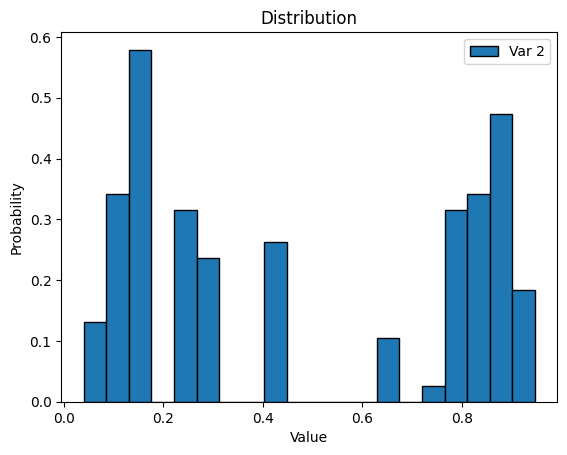

[0.42105263 0.21052632 0.31578947 0.02631579 0.         0.
 0.26315789 0.         0.         0.         0.         0.07894737
 0.02631579 0.         0.02631579 0.31578947 0.34210526 0.47368421
 0.02631579 0.39473684]


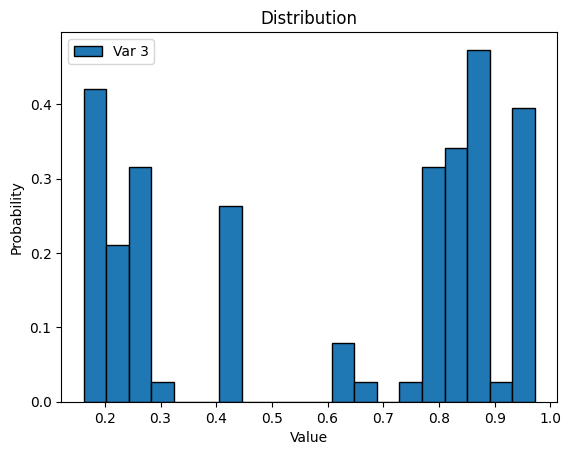

[0.13157895 0.39473684 0.42105263 0.         0.31578947 0.23684211
 0.         0.         0.21052632 0.05263158 0.         0.
 0.         0.         0.10526316 0.         0.02631579 0.
 0.65789474 0.47368421]


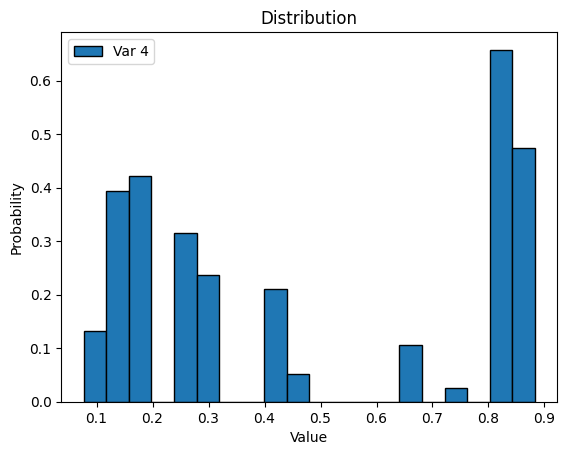

********************  # ESS values = 3.6387208788473004  ********************


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


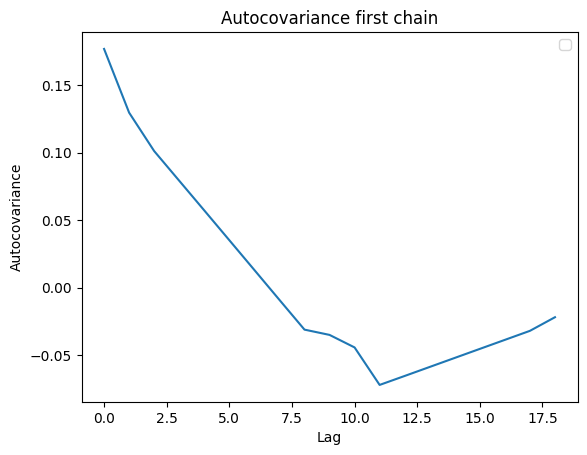

the difference between estimated values [0.0228023  0.97094975 1.578949   1.7645269 ]
 the difference between outputs of two models are [0.11030686 2.95588472 2.65804851 3.26454043]


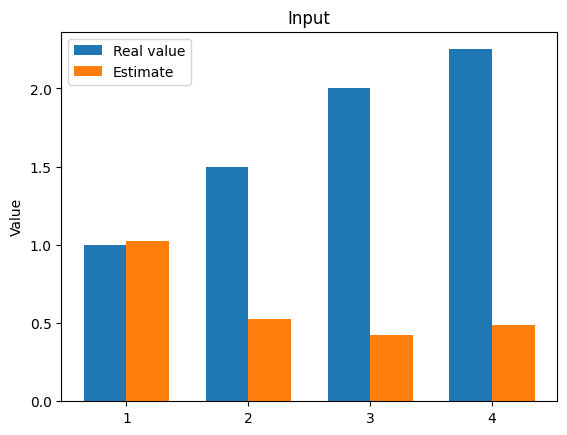

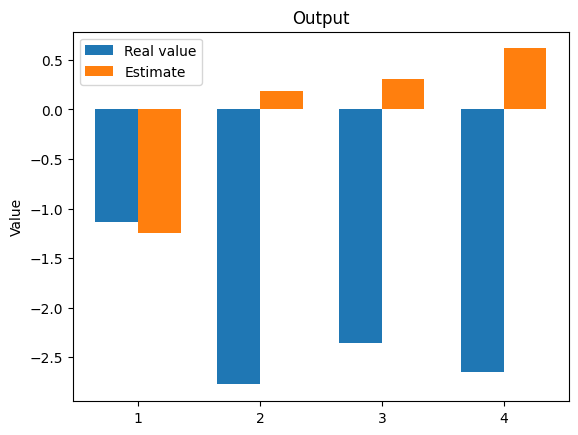

The function inverse_cuqi took 4.294971227645874 seconds.


In [12]:
estimate_MF=final_model.inverse_cuqi(mean_prior, sd_noise=sigma, proposal_sd=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True)


In [ ]:
estimate_LF=modelLF.inverse_cuqi(mean_prior, sd_noise=sigma, proposal_sd=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True)


In [ ]:
estimate_HF=modelHF.inverse_cuqi(mean_prior, sd_noise=sigma, proposal_sd=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True)


# MCMC using tinyDA

In [ ]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([0.2,0.3,0.4,0.45])*5
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.2
sigma=0.3
rwmh_cov = np.eye(len(real_x)) *3# !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =2000
burnin = 1000
n_chains=2

# Multifidelity

real values are [1.   1.5  2.   2.25]
Sampling chain 1/2


Running chain, α = 0.25: 100%|██████████| 2000/2000 [04:56<00:00,  6.75it/s]


Sampling chain 2/2


Running chain, α = 0.19: 100%|██████████| 2000/2000 [05:00<00:00,  6.66it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.095 1.925 1.875 2.001]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.095  0.072   0.956    1.219      0.004    0.003     280.0     359.0   
x1  1.925  0.449   1.289    2.865      0.193    0.156       9.0      35.0   
x2  1.875  0.518   1.252    2.922      0.249    0.206       8.0      56.0   
x3  2.001  0.393   1.410    2.857      0.068    0.049      36.0      86.0   

    r_hat  
x0   1.01  
x1   1.21  
x2   1.31  
x3   1.04  
Autocorrelation...
the difference between estimated values [0.095 0.425 0.125 0.249]
 the difference between outputs of two models are [0.45510173 0.08859824 0.06745575 0.31355637]


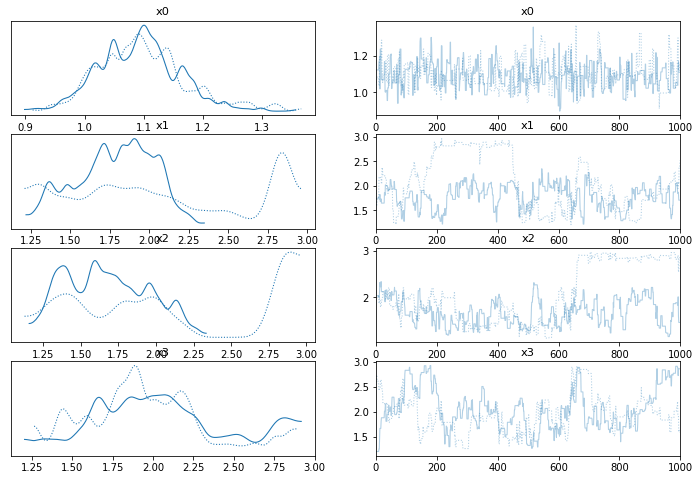

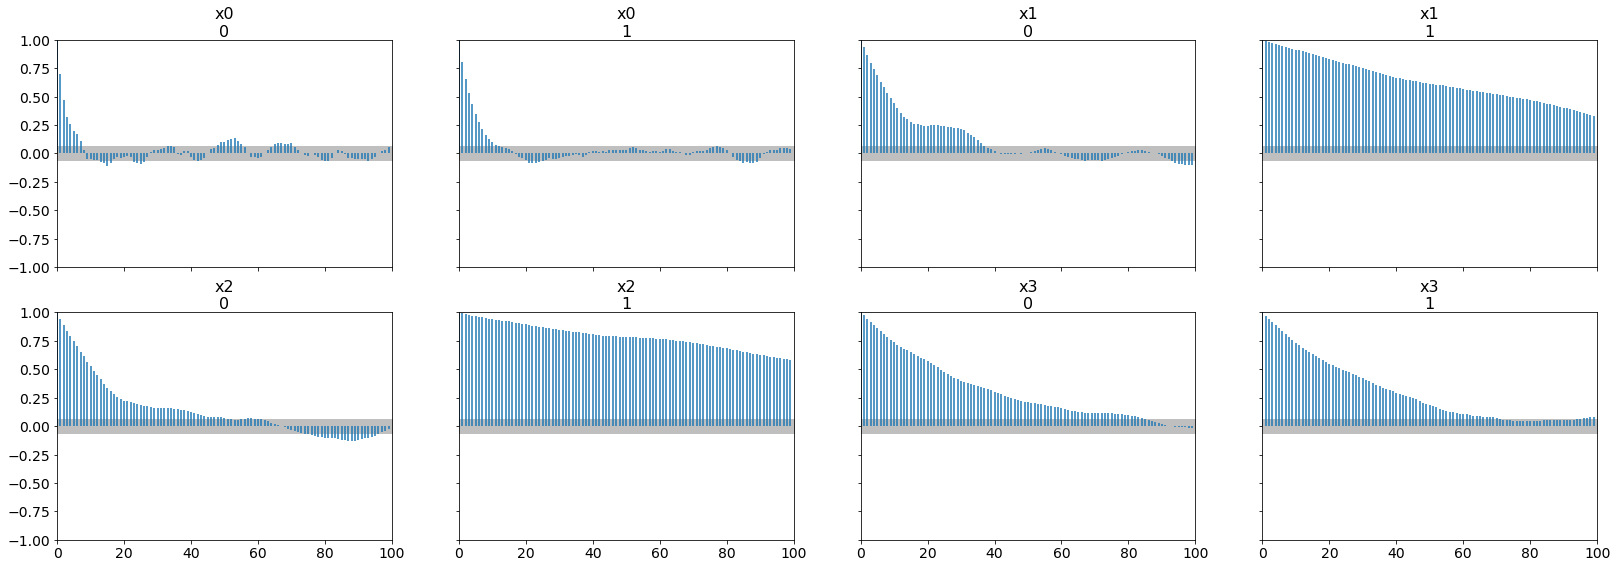

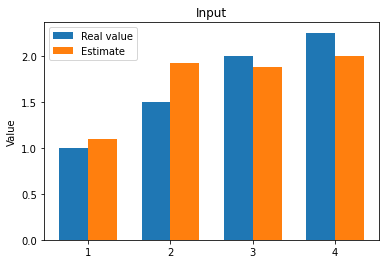

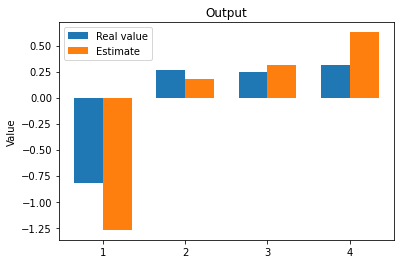

The function inverse took 633.0662746429443 seconds.


In [ ]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

### Low Fidelity

real values are [1.   1.5  2.   2.25]
Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 2000/2000 [02:26<00:00, 13.69it/s]


Sampling chain 2/2


Running chain, α = 0.11: 100%|██████████| 2000/2000 [02:29<00:00, 13.41it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.471 2.069 0.539 0.545]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.471  0.090   0.304    0.629      0.008    0.005     149.0     116.0   
x1  2.069  1.608   0.333    3.738      1.131    0.957       3.0      77.0   
x2  0.539  0.140   0.300    0.795      0.016    0.012      76.0     111.0   
x3  0.545  0.262   0.129    0.913      0.062    0.045      20.0      39.0   

    r_hat  
x0   1.02  
x1   1.86  
x2   1.03  
x3   1.10  
Autocorrelation...
the difference between estimated values [0.529 0.569 1.461 1.705]
 the difference between outputs of two models are [1.0037377 1.2459903 3.3615532 4.0337534]


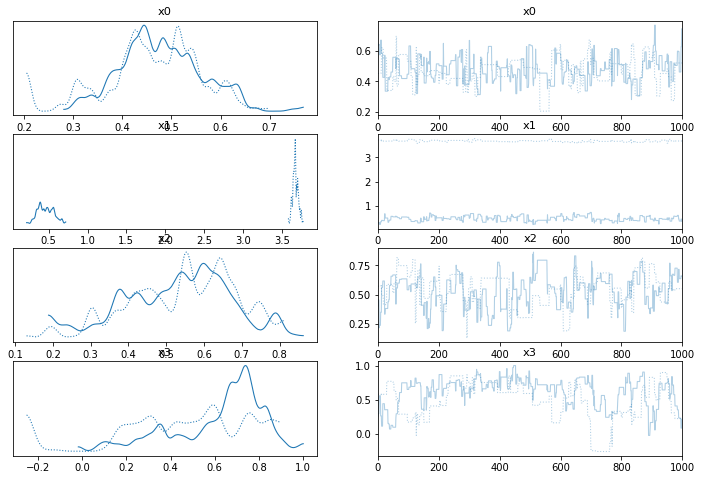

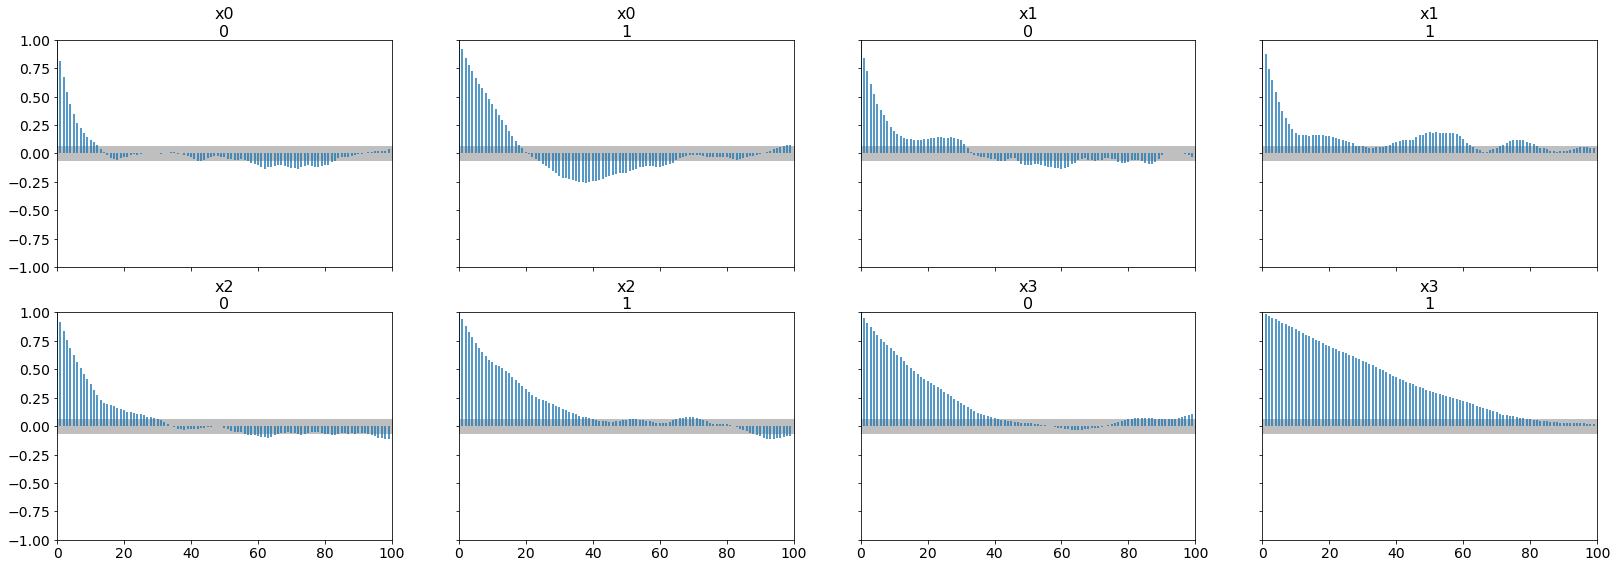

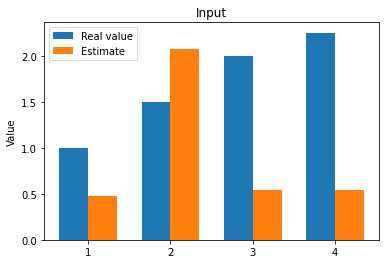

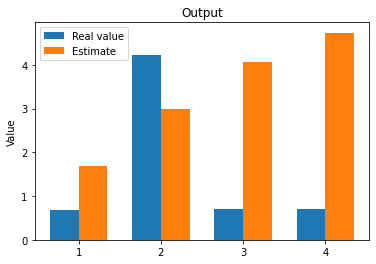

The function inverse took 313.55796456336975 seconds.


In [ ]:
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)


## High fidelity


real values are [1.   1.5  2.   2.25]


Sampling chain 1/2


Running chain, α = 0.64: 100%|██████████| 2000/2000 [02:31<00:00, 13.22it/s]


Sampling chain 2/2


Running chain, α = 0.13: 100%|██████████| 2000/2000 [02:37<00:00, 12.71it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.099 1.979 1.911 1.93 ]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.099  0.825   0.965    2.959      0.567    0.484       3.0      97.0   
x1  1.979  0.530   0.948    2.864      0.267    0.205       4.0      10.0   
x2  1.911  0.549   1.005    2.916      0.220    0.163       7.0      20.0   
x3  1.930  0.531   0.907    2.830      0.218    0.162       7.0      13.0   

    r_hat  
x0   1.85  
x1   1.39  
x2   1.21  
x3   1.23  
Autocorrelation...
the difference between estimated values [1.099 0.479 0.089 0.32 ]
 the difference between outputs of two models are [1.0179653  0.63023484 0.1066339  0.27656645]


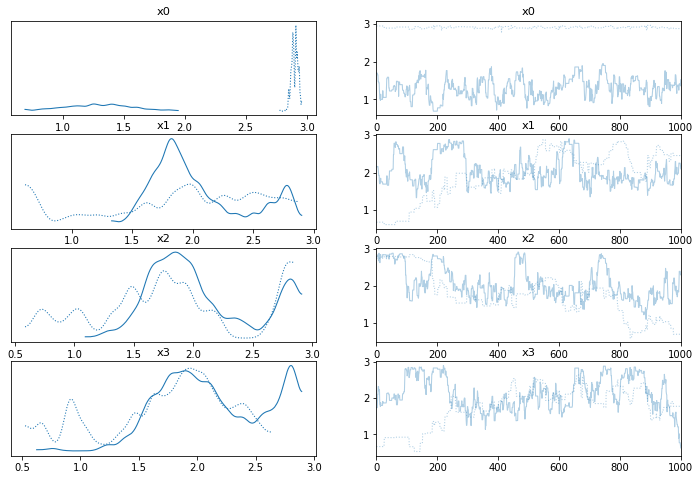

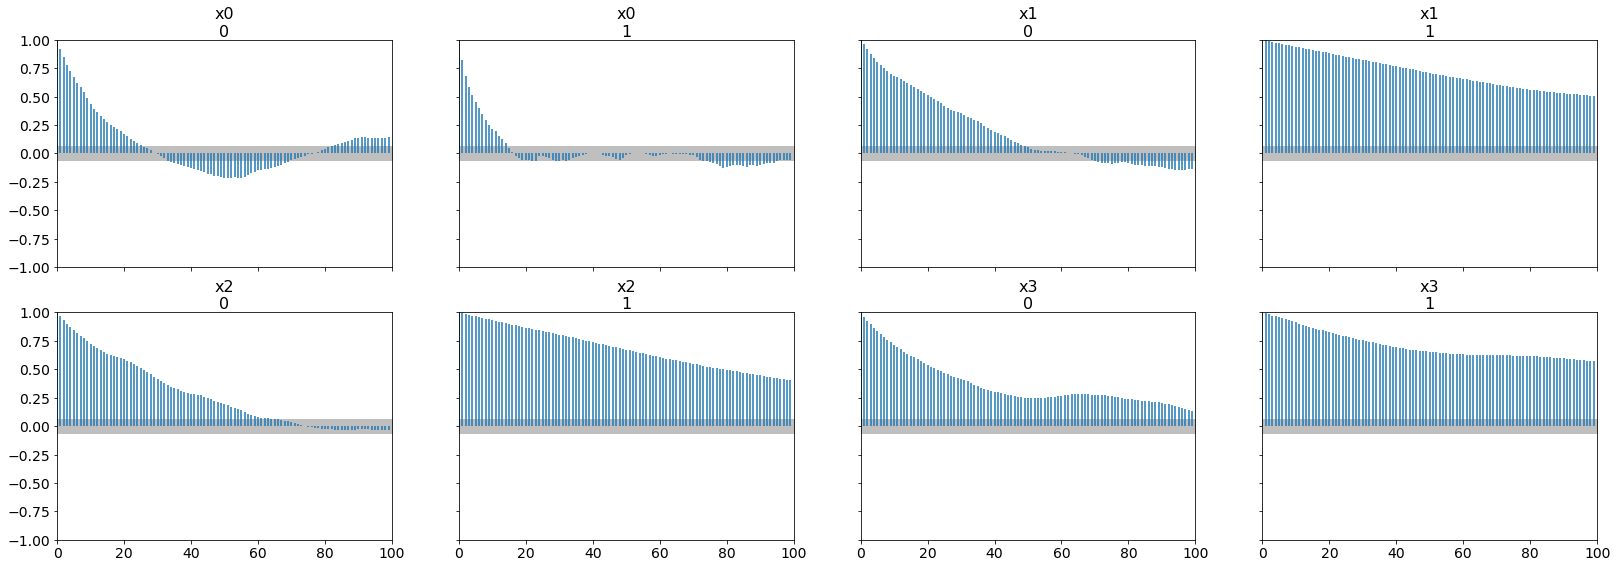

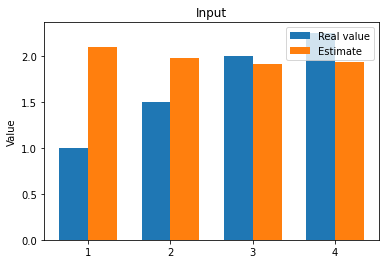

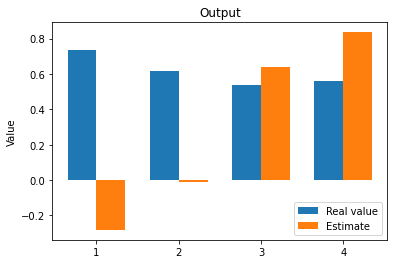

The function inverse took 312.9890706539154 seconds.


In [ ]:
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)